> **Chapter 12, Part 4** | Advanced lens. **Focus:** the skeleton of a fractal network and box-renormalization as a test for self-similar structure across scales.

# Skeletons, Hubs, and Renormalization

A fractal network has a structural feature that random networks do not: when you coarse-grain it by replacing each box with a super-node, the coarsened graph still looks like the original. Renormalization is the test.

The skeleton (Goh, Salvi, Kahng, and Kim, 2006) is the spanning subgraph that carries the fractal backbone. For most real fractal networks the skeleton is a tree formed by the highest-betweenness or longest-multiplicity edges. The non-fractal counterpart loses its shape after one coarse-graining step.

## Outputs

- a skeleton extractor based on the maximum-betweenness spanning subgraph
- a single-step box renormalization function that replaces boxes with super-nodes
- a side-by-side comparison: fractal network keeps its degree distribution shape after one renormalization, Erdos-Renyi does not

## Supporting reading

- Goh, K.-I., Salvi, G., Kahng, B., and Kim, D. (2006). Skeleton and fractal scaling in complex networks. *Phys. Rev. Lett.* 96, 018701.
- Song, C., Havlin, S., and Makse, H. A. (2005). Self-similarity of complex networks. *Nature* 433, 392-395.
- Rozenfeld, H. D., Havlin, S., and ben-Avraham, D. (2007). Fractal and transfractal recursive scale-free nets. *New J. Phys.* 9, 175.

## Failure note

If the renormalized graph looks identical to the original at the coarsest scale, you probably have a small-graph effect. Renormalization on a 30-node graph is informational but not structural.

## How I would debug this

Renormalize the Sierpinski-like graph from 12.3 first. The coarsened version should still look triangular. If it does not, the box-cover at the chosen `l_b` is not partitioning the graph cleanly.


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter


def max_betweenness_skeleton(g: nx.Graph) -> nx.Graph:
    """Skeleton: maximum spanning forest by edge betweenness centrality.

    Compute edge betweenness, then build a maximum spanning tree using those
    centralities as edge weights. The result is a tree-like backbone that
    captures the network's most-traversed paths.
    """
    eb = nx.edge_betweenness_centrality(g)
    h = nx.Graph()
    h.add_nodes_from(g.nodes())
    for (u, v), w in eb.items():
        h.add_edge(u, v, weight=w)
    return nx.maximum_spanning_tree(h)


def renormalize(g: nx.Graph, l_b: int) -> nx.Graph:
    """Replace each box with a super-node; super-nodes are adjacent iff any
    pair of original nodes (one in each box) is adjacent in g."""
    dist = dict(nx.all_pairs_shortest_path_length(g))
    aux = nx.Graph()
    aux.add_nodes_from(g.nodes())
    nodes = list(g.nodes())
    for i, u in enumerate(nodes):
        for v in nodes[i + 1:]:
            if dist[u].get(v, np.inf) >= l_b:
                aux.add_edge(u, v)
    coloring = nx.coloring.greedy_color(aux, strategy="largest_first")
    coarse = nx.Graph()
    boxes = sorted(set(coloring.values()))
    coarse.add_nodes_from(boxes)
    for u, v in g.edges():
        cu, cv = coloring[u], coloring[v]
        if cu != cv:
            coarse.add_edge(cu, cv)
    return coarse


hsf: 125 -> 9 nodes after renormalization
er: 124 -> 25 nodes after renormalization


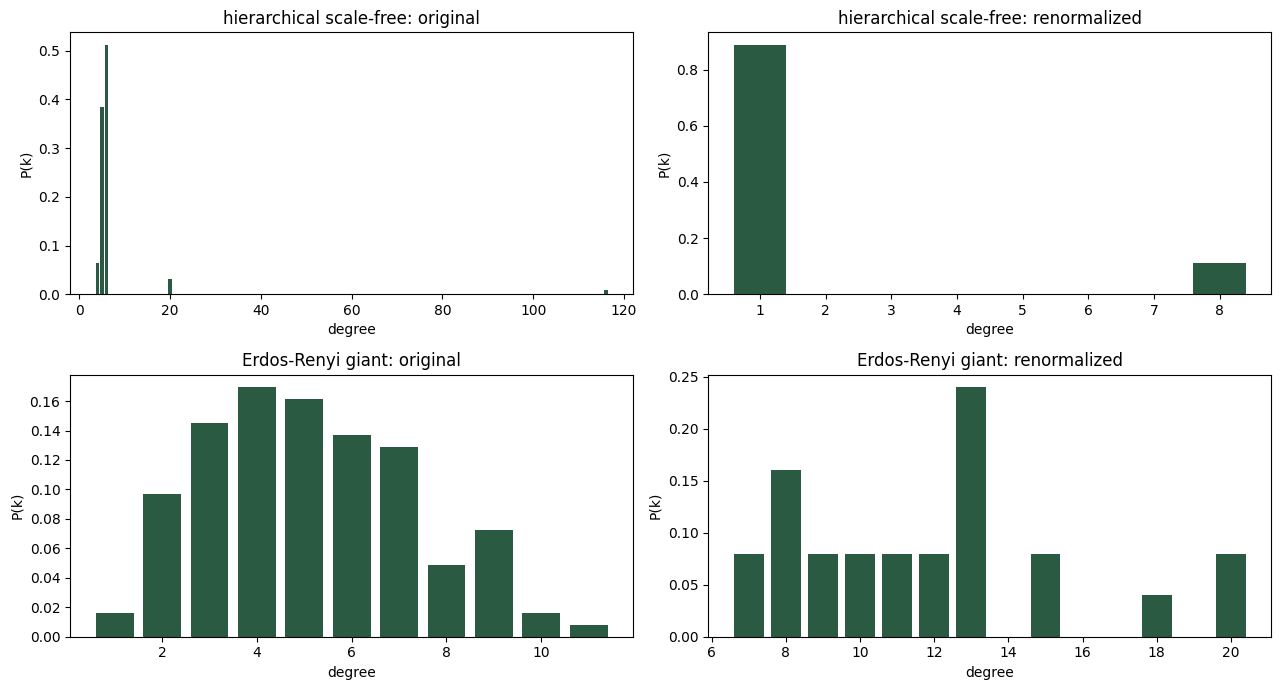

In [2]:
from typing import cast


def degree_dist(g: nx.Graph) -> tuple[np.ndarray, np.ndarray]:
    counts = Counter(d for _, d in g.degree())
    ks = np.array(sorted(counts.keys()))
    ps = np.array([counts[k] / max(g.number_of_nodes(), 1) for k in ks])
    return ks, ps


def hierarchical_scale_free(generations: int = 3) -> nx.Graph:
    base = nx.Graph()
    base.add_edges_from([(0, i) for i in range(1, 5)])
    base.add_edges_from([(i, j) for i in range(1, 5) for j in range(i + 1, 5)])
    g = base.copy()
    for _ in range(generations - 1):
        offset = g.number_of_nodes()
        new_size = g.number_of_nodes()
        copies = []
        for c in range(4):
            mapping = {n: n + offset + c * new_size for n in g.nodes()}
            copies.append(nx.relabel_nodes(g, mapping))
        merged = nx.Graph()
        merged.add_edges_from(g.edges())
        for c in copies:
            merged.add_edges_from(c.edges())
        peripheral = [n for n in g.nodes() if n != 0]
        for c_idx in range(4):
            for periph in peripheral:
                periph_in_copy = periph + offset + c_idx * new_size
                merged.add_edge(periph_in_copy, 0)
        g = merged
    return g


hsf = hierarchical_scale_free(generations=3)
er = nx.erdos_renyi_graph(hsf.number_of_nodes(), 0.04, seed=7)
giant = max(nx.connected_components(er), key=len)
er = er.subgraph(giant).copy()

hsf_renorm = renormalize(hsf, l_b=3)
er_renorm = renormalize(er, l_b=3)

print("hsf:", hsf.number_of_nodes(), "->", hsf_renorm.number_of_nodes(), "nodes after renormalization")
print("er:", er.number_of_nodes(), "->", er_renorm.number_of_nodes(), "nodes after renormalization")

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

for ax, g, title in [
    (axes[0, 0], hsf, "hierarchical scale-free: original"),
    (axes[0, 1], hsf_renorm, "hierarchical scale-free: renormalized"),
    (axes[1, 0], er, "Erdos-Renyi giant: original"),
    (axes[1, 1], er_renorm, "Erdos-Renyi giant: renormalized"),
]:
    ks, ps = degree_dist(g)
    ax.bar(ks, ps, color="#2b5a43")
    ax.set_xlabel("degree")
    ax.set_ylabel("P(k)")
    ax.set_title(title)
plt.tight_layout()
plt.show()


In [3]:
skel = max_betweenness_skeleton(hsf)
print("skeleton edges:", skel.number_of_edges(), "of", hsf.number_of_edges(), "original edges")
print("skeleton ratio:", round(skel.number_of_edges() / hsf.number_of_edges(), 3))

skel_er = max_betweenness_skeleton(er)
print("\nER skeleton edges:", skel_er.number_of_edges(), "of", er.number_of_edges())
print("ER skeleton ratio:", round(skel_er.number_of_edges() / er.number_of_edges(), 3))


skeleton edges: 124 of 426 original edges
skeleton ratio: 0.291

ER skeleton edges: 123 of 319
ER skeleton ratio: 0.386


## Reading the result

After one box-renormalization at `l_b = 3`, the hierarchical scale-free network keeps a recognizable degree distribution: a small number of high-degree super-nodes and a long tail of low-degree super-nodes. The Erdos-Renyi giant component renormalizes to a near-complete graph among super-nodes, because random connectivity routes through almost every box.

The skeleton ratios reinforce the same story. A fractal-like network concentrates traversal on a small spanning tree (low skeleton ratio). A random network spreads betweenness across edges, so the maximum spanning tree is a much smaller fraction of the original.

## Where this can go wrong

- **`edge_betweenness_centrality` is O(N * E).** For graphs with more than a few thousand edges, sample the centrality on a subset of source nodes (`k` parameter in NetworkX).
- **Renormalization at the wrong `l_b`** collapses the graph to one or two super-nodes and the test loses meaning. Pick `l_b` such that the renormalized graph keeps at least 30 super-nodes.
- **Skeleton extraction is unstable on isomorphic edges.** When several edges have identical betweenness, the choice of skeleton edge depends on iteration order. The qualitative result (low ratio for fractal, high for random) survives this; the exact set of skeleton edges does not.

## Exercise

1. renormalize the Sierpinski-like graph from 12.3 at `l_b = 2`. How many super-nodes does the coarsened graph have?
2. compute the skeleton ratio for both the Karate club and a random graph of the same size. Which is structurally tighter?
3. iterate renormalization twice on the hierarchical scale-free network. Does the second-step coarsened graph still look self-similar?
